# Laboratorio 9: Datos SintéticosÇ
###  1. ¿Por qué una empresa podría no compartir sus datos reales?

* **Privacidad y Regulaciones Legales:** Leyes estrictas a nivel mundial (como el *GDPR* en Europa o la *LFPDPPP* en México) prohíben compartir datos personales (nombres, tarjetas, historiales médicos) sin un consentimiento explícito. Las multas pueden ser millonarias.
* **Secretos Comerciales y Competitividad:** Los datos operativos revelan estrategias, márgenes de ganancia y el comportamiento exacto de sus clientes. Si la competencia accede a ellos, pierden su ventaja en el mercado.
* **Riesgos de Ciberseguridad:** Centralizar o transferir bases de datos reales incrementa la superficie de ataque. Si los datos caen en manos equivocadas mediante una filtración, la reputación de la empresa se destruiría.

  
###  2. ¿Qué sesgos existen al utilizar datos personales de los clientes?
1.  **Sesgo de Representación (Muestreo):** Si la base de datos tiene un 80% de registros de hombres de 20 a 30 años, cualquier decisión que tome el sistema será inexacta o injusta para mujeres u otros rangos de edad.
2.  **Sesgo Histórico:** Los datos reflejan cómo *era* el mundo, no cómo *debería* ser. Si históricamente se le otorgaron menos créditos bancarios a un grupo social por prejuicios del pasado, el algoritmo aprenderá a seguir negándoselos de forma automática.
3.  **Sesgo de Confirmación:** Diseñar la recolección de datos orientada a demostrar una hipótesis previa, ignorando de forma masiva los comportamientos de las minorías.


###  3. ¿Crees que es posible entrenar un modelo ML sin datos reales?

**Sí, absolutamente.** De hecho, es una de las tendencias más fuertes en la industria de la Inteligencia Artificial. Esto se logra mediante dos enfoques principales:

In [1]:
import pandas as pd

In [7]:
#Necesito instalar Faker con pip install Faker
from faker import Faker

In [3]:
import random

In [6]:
#Crear instancia de Faker 
fake = Faker ("es_MX")

In [34]:
#Generamos datos sinteticos: 100 registros
datos = []
for i in range(1000):
    datos.append({
        "id_usurio": i + 1,
        "nombre": fake.name(),
        "Correo": fake.email(),
        "edad": random.randint(18, 65),
        "seguidores": random.randint(100, 50000),
        "plataforma": random.choice(
            ["Tiktok", "Youtube", "Instagram"]
        )
    })

In [35]:
df = pd.DataFrame(datos)

In [36]:
df.head()

,id_usurio,nombre,Correo,edad,seguidores,plataforma
0,1,Alonso Lucas Cervantes Rascón,yrosales@example.net,36,11984,Youtube
1,2,Gerónimo Muro,gonzalo56@example.org,47,45154,Youtube
2,3,Ing. Martha Montaño,davidbalderas@example.net,41,110,Instagram
3,4,Pamela Rael,debora33@example.org,18,6714,Instagram
4,5,Carlos Flavio Moya Rojas,bcarrera@example.org,18,46261,Tiktok


In [37]:
#Exploracion del datasets
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usurio   1000 non-null   int64 
 1   nombre      1000 non-null   object
 2   Correo      1000 non-null   object
 3   edad        1000 non-null   int64 
 4   seguidores  1000 non-null   int64 
 5   plataforma  1000 non-null   object
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


In [38]:
#Estadistica descriptiva
df.describe(include= "all")

,id_usurio,nombre,Correo,edad,seguidores,plataforma
count,1000.000000,1000,1000,1000.000000,1000.00000,1000
unique,NaN,1000,1000,NaN,NaN,3
top,NaN,Alonso Lucas Cervantes Rascón,yrosales@example.net,NaN,NaN,Youtube
freq,NaN,1,1,NaN,NaN,334
mean,500.500000,NaN,NaN,41.102000,24624.03900,NaN
std,288.819436,NaN,NaN,13.695516,14529.02781,NaN
min,1.000000,NaN,NaN,18.000000,110.00000,NaN
25%,250.750000,NaN,NaN,29.000000,11440.25000,NaN
50%,500.500000,NaN,NaN,41.000000,25393.00000,NaN
75%,750.250000,NaN,NaN,53.000000,37239.00000,NaN


In [39]:
#Importar librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

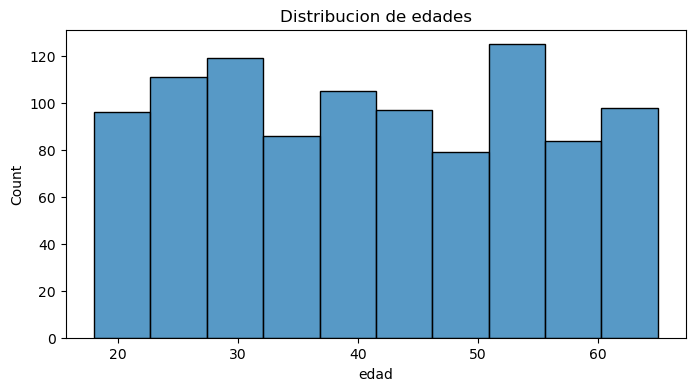

In [40]:
#Distribucion de edades
plt.figure(figsize=(8, 4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribucion de edades")
plt.show()

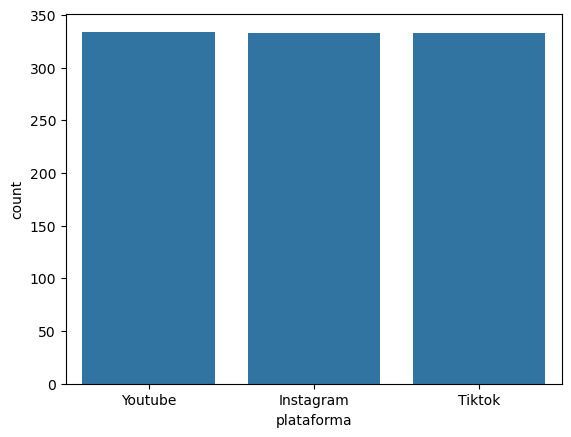

In [41]:
#usuarios por plataforma
sns.countplot(
    x= "plataforma",
    data=df
)
plt.show()

In [42]:
#Generamos una copia para contaminarla
df_sucio = df.copy()

In [43]:
#Le colocamos valores nulos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "nombre"] = None

In [44]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usurio   1000 non-null   int64 
 1   nombre      995 non-null    object
 2   Correo      1000 non-null   object
 3   edad        1000 non-null   int64 
 4   seguidores  1000 non-null   int64 
 5   plataforma  1000 non-null   object
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


In [45]:
#Edades invalidas
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "edad"] = -10

In [46]:
df_sucio.describe()["edad"]

count    1000.000000
mean       40.842000
std        14.138208
min       -10.000000
25%        29.000000
50%        40.000000
75%        53.000000
max        65.000000
Name: edad, dtype: float64

In [47]:
#Seguidores imposibles
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "seguidores"] = 5000000

In [48]:
df_sucio.describe()["seguidores"]

count    1.000000e+03
mean     4.951807e+04
std      3.514058e+05
min      1.100000e+02
25%      1.146875e+04
50%      2.566050e+04
75%      3.751900e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [49]:
#Generamos Correo Invalidos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "Correo"] = "Correo_Invalido"


In [50]:
df_sucio.describe(include=["object"])

,nombre,Correo,plataforma
count,995,1000,1000
unique,995,996,3
top,Alonso Lucas Cervantes Rascón,Correo_Invalido,Youtube
freq,1,5,334


In [52]:
df_sucio.isnull().sum()

id_usurio     0
nombre        5
Correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [56]:
#Estadisticas
df_sucio.describe(include="all")

,id_usurio,nombre,Correo,edad,seguidores,plataforma
count,1000.00,995,1000,1000.00,1000.00,1000
unique,NaN,995,996,NaN,NaN,3
top,NaN,Alonso Lucas Cervantes Rascón,Correo_Invalido,NaN,NaN,Youtube
freq,NaN,1,5,NaN,NaN,334
mean,500.50,NaN,NaN,40.84,49518.07,NaN
std,288.82,NaN,NaN,14.14,351405.77,NaN
min,1.00,NaN,NaN,-10.00,110.00,NaN
25%,250.75,NaN,NaN,29.00,11468.75,NaN
50%,500.50,NaN,NaN,40.00,25660.50,NaN
75%,750.25,NaN,NaN,53.00,37519.00,NaN


In [55]:
pd.set_option('display.float_format', lambda x: '%.2f' %x)